# 排序数组：



到目前为止，我们主要关注的是使用NumPy访问和操作数组数据的工具。

本章将讨论与NumPy数组中值排序相关的算法。

这些算法是计算机科学入门课程中的热门话题：如果你曾经上过这样的课程，你可能会梦见（或者根据你的性格，做噩梦）*插入排序*、*选择排序*、*归并排序*、*快速排序*、*冒泡排序*等许多其他算法。

它们都是实现相似任务的方法：对列表或数组中的值进行排序。

Python提供了一些内置函数和方法，用于对列表及其他可迭代对象进行排序。`sorted`函数接受一个列表，并返回其已排序版本。

In [1]:
L = [3, 1, 4, 1, 5, 9, 2, 6]
sorted(L)  # returns a sorted copy

[1, 1, 2, 3, 4, 5, 6, 9]

相较之下，列表的 `sort` 方法将对列表进行原地排序：

In [2]:
L.sort()  # acts in-place and returns None
print(L)

[1, 1, 2, 3, 4, 5, 6, 9]


Python的排序方法非常灵活，可以处理任何可迭代对象。例如，下面我们对一个字符串进行排序：


In [3]:
sorted('python')

['h', 'n', 'o', 'p', 't', 'y']

这些内置的排序方法很方便，但正如之前所讨论的，Python 值的动态性意味着它们在性能上不如专门为均匀数字数组设计的例程。

这就是 NumPy 排序例程发挥作用的地方。

## NumPy中的快速排序：np.sort和np.argsort

`np.sort`函数类似于Python内置的`sorted`函数，能够高效地返回数组的排序副本。

In [4]:
import numpy as np

x = np.array([2, 1, 4, 3, 5])
np.sort(x)

array([1, 2, 3, 4, 5])

与Python列表的`sort`方法类似，您也可以使用数组的`sort`方法对数组进行就地排序。

In [5]:
x.sort()
print(x)

[1 2 3 4 5]


相关函数是 `argsort`，它返回的是排序元素的 *索引*：

In [6]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)
print(i)

[1 0 3 2 4]


结果的第一个元素给出了最小元素的索引，第二个值给出了第二小元素的索引，以此类推。

然后可以使用这些索引（通过花式索引）来构建所需的排序数组。

In [7]:
x[i]

array([1, 2, 3, 4, 5])

您将在本章后面看到`argsort`的应用。

### 按行或列排序：

“您将在本章后面看到`argsort`的应用。

### 按行或列排序”

NumPy排序算法的一个有用特性是能够使用`axis`参数对多维数组的特定行或列进行排序。例如：

In [8]:
rng = np.random.default_rng(seed=42)
X = rng.integers(0, 10, (4, 6))
print(X)

[[0 7 6 4 4 8]
 [0 6 2 0 5 9]
 [7 7 7 7 5 1]
 [8 4 5 3 1 9]]


In [9]:
# sort each column of X
np.sort(X, axis=0)

array([[0, 4, 2, 0, 1, 1],
       [0, 6, 5, 3, 4, 8],
       [7, 7, 6, 4, 5, 9],
       [8, 7, 7, 7, 5, 9]])

In [10]:
# sort each row of X
np.sort(X, axis=1)

array([[0, 4, 4, 6, 7, 8],
       [0, 0, 2, 5, 6, 9],
       [1, 5, 7, 7, 7, 7],
       [1, 3, 4, 5, 8, 9]])

请注意，这将每一行或列视为独立的数组，因此行或列值之间的任何关系都将丢失！

## 部分排序：划分

有时我们并不需要对整个数组进行排序，而只是想找到数组中 *k* 个最小的值。NumPy 通过 `np.partition` 函数实现了这一功能。`np.partition` 接受一个数组和一个数字 *K*；结果是一个新数组，其中最小的 *K* 个值位于划分的左侧，其余值位于右侧。

In [11]:
x = np.array([7, 2, 3, 1, 6, 5, 4])
np.partition(x, 3)

array([1, 2, 3, 4, 5, 6, 7])

请注意，结果数组中的前三个值是原数组中最小的三个值，其余位置则包含其他值。

在这两个分区内，元素的顺序是任意的。

与排序类似，我们可以沿着多维数组的任意轴进行划分。

In [12]:
np.partition(X, 2, axis=1)

array([[0, 4, 4, 6, 7, 8],
       [0, 0, 2, 5, 6, 9],
       [1, 5, 7, 7, 7, 7],
       [1, 3, 4, 5, 8, 9]])

结果是一个数组，其中每行的前两个位置包含该行中的最小值，其余值填充剩余的位置。

最后，正如存在计算排序索引的 `np.argsort` 函数一样，还有一个计算分区索引的 `np.argpartition` 函数。

我们将在下一节中看到这两者的实际应用。

## 示例：k-最近邻

我们将快速了解如何使用 `argsort` 函数沿多个轴找到集合中每个点的最近邻。

首先，我们将在二维平面上创建一组随机的10个点。

按照标准惯例，我们将这些点排列成一个 $10\times 2$ 的数组。

In [13]:
X = rng.random((10, 2))

为了更好地理解这些点的分布情况，我们生成一个快速的散点图（见下图）：

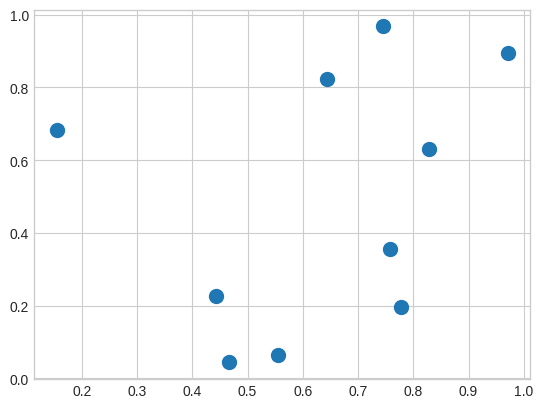

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(X[:, 0], X[:, 1], s=100);

现在我们将计算每对点之间的距离。

请记住，两个点之间的平方距离是各个维度上差异平方的总和；

利用NumPy提供的高效广播（[数组计算：广播](02.05-Computation-on-arrays-broadcasting.ipynb)）和聚合（[聚合：最小值、最大值及其间的一切](02.04-Computation-on-arrays-aggregates.ipynb)）例程，我们可以用一行代码计算平方距离矩阵。

In [16]:
dist_sq = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=-1)

这项操作包含了很多内容，如果您对NumPy的广播规则不熟悉，可能会感到有些困惑。当您遇到这样的代码时，将其分解为各个组成步骤是很有用的。

In [17]:
# for each pair of points, compute differences in their coordinates
differences = X[:, np.newaxis] - X[np.newaxis, :]
differences.shape

(10, 10, 2)

In [18]:
# square the coordinate differences
sq_differences = differences ** 2
sq_differences.shape

(10, 10, 2)

In [19]:
# sum the coordinate differences to get the squared distance
dist_sq = sq_differences.sum(-1)
dist_sq.shape

(10, 10)

作为我们逻辑的快速检查，我们应该看到这个矩阵的对角线（即每个点与自身之间的距离集合）全为零。

In [20]:
dist_sq.diagonal()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

经过转换的成对平方距离后，我们现在可以使用 `np.argsort` 对每一行进行排序。最左侧的列将提供最近邻居的索引。

In [21]:
nearest = np.argsort(dist_sq, axis=1)
print(nearest)

[[0 9 3 5 4 8 1 6 2 7]
 [1 7 2 6 4 8 3 0 9 5]
 [2 7 1 6 4 3 8 0 9 5]
 [3 0 4 5 9 6 1 2 8 7]
 [4 6 3 1 2 7 0 5 9 8]
 [5 9 3 0 4 6 8 1 2 7]
 [6 4 2 1 7 3 0 5 9 8]
 [7 2 1 6 4 3 8 0 9 5]
 [8 0 1 9 3 4 7 2 6 5]
 [9 0 5 3 4 8 6 1 2 7]]


注意，第一列按顺序给出了数字0到9：这是因为每个点的最近邻是它自己，这是我们所期望的。

在这里使用完全排序实际上做了比我们需要更多的工作。如果我们只对最近的 $k$ 个邻居感兴趣，我们只需对每一行进行分区，使得最小的 $k + 1$ 个平方距离排在前面，其余较大的距离填充数组中的其他位置。我们可以使用 `np.argpartition` 函数来实现这一点。

In [22]:
K = 2
nearest_partition = np.argpartition(dist_sq, K + 1, axis=1)

为了可视化这个邻居网络，我们快速绘制点，并用线表示每个点与其两个最近邻的连接（见下图）：

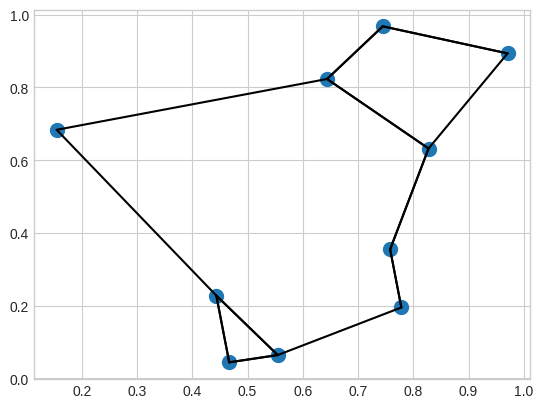

In [23]:
plt.scatter(X[:, 0], X[:, 1], s=100)

# draw lines from each point to its two nearest neighbors
K = 2

for i in range(X.shape[0]):
    for j in nearest_partition[i, :K+1]:
        # plot a line from X[i] to X[j]
        # use some zip magic to make it happen:
        plt.plot(*zip(X[j], X[i]), color='black')

每个图中的点都有线条连接到其两个最近的邻居。

乍一看，某些点有超过两条线似乎很奇怪：这是因为如果点 A 是点 B 的两个最近邻居之一，并不意味着点 B 也是点 A 的两个最近邻居之一。

尽管这种方法的广播和逐行排序可能看起来不如编写循环直接，但事实证明，这是一种在 Python 中高效处理此数据的方法。

你可能会想通过手动遍历数据并单独对每组邻居进行排序来执行相同类型的操作，但这几乎肯定会导致比我们使用的向量化版本更慢的算法。这种方法的优雅之处在于，它以一种与输入数据大小无关的方式编写：我们可以同样轻松地计算 100 或 1,000,000 个任意维度中点之间的邻居，而代码看起来是一样的。

最后，我要指出的是，在进行非常大的最近邻搜索时，有基于树和/或近似算法可以扩展为 $\mathcal{O}[N\log N]$ 或更好，而不是暴力算法所需的 $\mathcal{O}[N^2]$。其中一个例子是 KD-Tree，[已在 Scikit-Learn 中实现](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html)。